In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

process = Path("../Data/Processed")
modelf = Path("../Models/Forecasting")
figure = Path("../Reports/Figure")


daily_df = pd.read_csv(process / "retail_daily_sales_timeseries.csv",parse_dates=["Date"])

print("Dataset shape:",daily_df.shape)
print("\nColumns:",daily_df.columns.tolist())
print("\nDate range:")
print(daily_df["Date"].min(),"to",daily_df["Date"].max())

Dataset shape: (739, 15)

Columns: ['Date', 'DailyRevenue', 'DailyQuantity', 'DailyOrders', 'DailyCustomers', 'Revenue_MA7', 'Revenue_MA30', 'Quantity_MA7', 'Quantity_MA30', 'Revenue_Lag1', 'Revenue_Lag7', 'Revenue_Lag30', 'Quantity_Lag1', 'Quantity_Lag7', 'Quantity_Lag30']

Date range:
2009-12-01 00:00:00 to 2011-12-09 00:00:00


In [4]:
prophet_df = daily_df[["Date","DailyQuantity"]].copy()

prophet_df = prophet_df.rename(columns={"Date":"ds","DailyQuantity":"y"})

print("Prophet dataset shape:",prophet_df.shape)
print("\nMissing values:")
print(prophet_df.isnull().sum())

prophet_df.head()

Prophet dataset shape: (739, 2)

Missing values:
ds    0
y     0
dtype: int64


,ds,y
0,2009-12-01,24335
1,2009-12-02,29679
2,2009-12-03,48009
3,2009-12-04,19954
4,2009-12-05,5119


The final date was excluded because it contains incomplete transaction data and does not represent a complete business day.

In [12]:
last_date = daily_df["Date"].max()

prophet_df = daily_df[daily_df["Date"] < last_date][["Date","DailyQuantity"]].copy()

prophet_df = prophet_df.rename(columns={"Date":"ds","DailyQuantity":"y"
})

print("Excluded incomplete date:",last_date)
print("Prophet dataset shape:",prophet_df.shape)
print("Date range:",prophet_df["ds"].min(),"to",prophet_df["ds"].max())

Excluded incomplete date: 2011-12-09 00:00:00
Prophet dataset shape: (738, 2)
Date range: 2009-12-01 00:00:00 to 2011-12-08 00:00:00


In [13]:
test_days = 30

train_df = prophet_df.iloc[:-test_days].copy() # It select all rows except the last 30
test_df = prophet_df.iloc[-test_days:].copy() # It select the last 30 rows

print("Training shape:",train_df.shape)
print("Testing shape:",test_df.shape)

print("\nTraining date range:",train_df["ds"].min(),"to",train_df["ds"].max())

print("\nTesting date range:",test_df["ds"].min(),"to",test_df["ds"].max())

Training shape: (708, 2)
Testing shape: (30, 2)

Training date range: 2009-12-01 00:00:00 to 2011-11-08 00:00:00

Testing date range: 2011-11-09 00:00:00 to 2011-12-08 00:00:00


In [6]:
%pip install prophet

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
   -- ------------------------------------- 0.8/12.1 MB 1.3 MB/s eta 0:00:09
   --- ------------------------------------ 1.0/12.1 MB 1.5 MB/s eta 0:00:08
   ----- ---------------------------------- 1.6/12.1 MB 1.8 MB/s eta 0:00:06
   ------ --------------------------------- 2.1/12.1 MB 1.8 MB/s eta 0:00:06
   -------- ------------------------------- 2.6/12.1 MB 1.9 MB/s eta 0:00:05
   ---------- ----------------------------- 3.1/12.1 MB 2.0 MB/s eta 0:00:05
   ------------ --------------------------- 3.7/12.1 MB 2.0 MB/s eta 0:00:05
   ------------ --------------------------- 3.9/12.1 MB 2.0 MB/s eta 0:00:05
   -------------- ------------------------- 4.5/12.1 MB 2.1 MB/s eta 0:00:04
   ----------------- ---------------------- 5.2/12.1 MB 2.2 MB/s eta 0:00:04
   -----------------


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
from prophet import Prophet

prophet_model = Prophet()
prophet_model.fit(train_df)

print("Prophet baseline model trained successfully.")

test_forecast = prophet_model.predict(test_df[["ds"]])

validation_df = test_df.merge(test_forecast[["ds","yhat","yhat_lower","yhat_upper"]],on="ds",how="left")
# ds: Forecast date , yhat: Predicted value
# yhat_lower: Minimum expected value , yhat_upper: Maximum expected value

print(validation_df.head())

# Calculate Metrics for accuracy assessment
from sklearn.metrics import mean_absolute_error,mean_squared_error

mae = mean_absolute_error(validation_df["y"],validation_df["yhat"])
rmse = np.sqrt(mean_squared_error(validation_df["y"],validation_df["yhat"]))

non_zero_df = validation_df[validation_df["y"] != 0].copy()
mape = np.mean(np.abs((non_zero_df["y"] - non_zero_df["yhat"]) / non_zero_df["y"])) * 100
wape = (np.abs(validation_df["y"] - validation_df["yhat"]).sum() / validation_df["y"].sum()) * 100

print("MAE:",round(mae,2))
print("RMSE:",round(rmse,2))
print("MAPE:",round(mape,2),"%")
print("WAPE:",round(wape,2),"%")

19:15:46 - cmdstanpy - INFO - Chain [1] start processing
19:15:46 - cmdstanpy - INFO - Chain [1] done processing


Prophet baseline model trained successfully.
          ds      y          yhat    yhat_lower    yhat_upper
0 2011-11-09  36888  21478.118293   9101.121494  35503.337047
1 2011-11-10  37955  25087.060220  12454.322764  37790.567343
2 2011-11-11  23844  18078.737878   5324.278650  30932.462806
3 2011-11-12      0   4565.767000  -7915.417449  16606.848732
4 2011-11-13  19610  14042.867800   1170.795813  26902.831032
MAE: 6399.68
RMSE: 7938.24
MAPE: 23.81 %
WAPE: 27.78 %


In [ ]:
validation_df["AbsoluteError"] = abs(validation_df["y"] - validation_df["yhat"])
validation_df[["ds","y","yhat","AbsoluteError"]].sort_values("AbsoluteError",ascending=False).head(10)

,ds,y,yhat,AbsoluteError
28,2011-12-07,41011,22557.823025,18453.176975
14,2011-11-23,38287,22017.970659,16269.029341
26,2011-12-05,38347,22359.919937,15987.080063
0,2011-11-09,36888,21478.118293,15409.881707
1,2011-11-10,37955,25087.060220,12867.939780
5,2011-11-14,32050,21550.141389,10499.858611
13,2011-11-22,31596,23275.957021,8320.042979
7,2011-11-16,29010,21748.044476,7261.955524
23,2011-12-02,25524,18888.516426,6635.483574
19,2011-11-28,27932,22089.993754,5842.006246


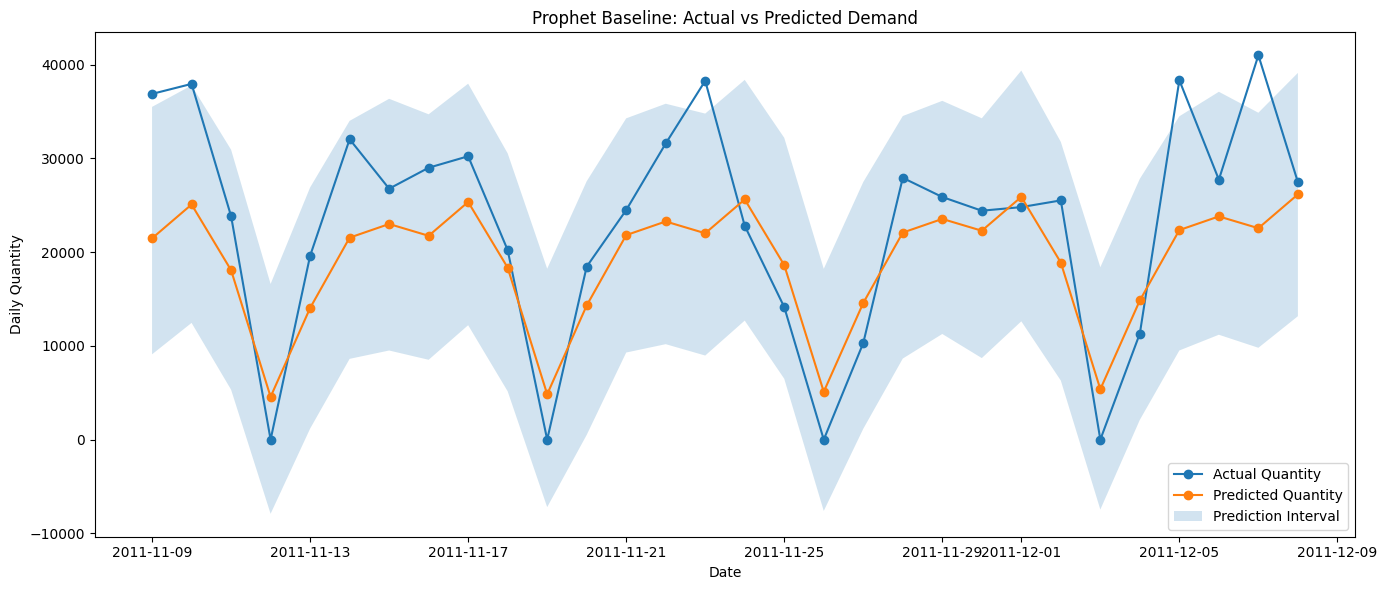

In [18]:
plt.figure(figsize=(14,6))
plt.plot(validation_df["ds"],validation_df["y"],label="Actual Quantity",marker="o")
plt.plot(validation_df["ds"],validation_df["yhat"],label="Predicted Quantity",marker="o")
plt.fill_between(validation_df["ds"],validation_df["yhat_lower"],validation_df["yhat_upper"],alpha=0.2,label="Prediction Interval")
plt.title("Prophet Baseline: Actual vs Predicted Demand")
plt.xlabel("Date")
plt.ylabel("Daily Quantity")
plt.legend()
plt.tight_layout()
plt.savefig("../Reports/Figure/5-Prophet_Baseline_Validation.png",dpi=300,bbox_inches="tight")
plt.show()